# Importing libraries and initial setup

This is a self contained notebook that contains the evaluation of the high-precision regressors. It has the functions for data loading, model creation, loading the weights, evaluating the models and plotting the results.

Ensure the required libraries are installed. The requirements can be found in the [requirements.txt](../requirements.txt) file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
# from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [2]:
torch.set_default_dtype(torch.float64)

### Load the config JSON/Dictionary here

Set the "data_dir" to where your current qqzz4l-nn directory exists. The path must contain these following folders

- test  
- test_mc  
- train  
- validate	
- validate_mc

For more detail of the config, refer the [github readme](https://github.com/talismanbrandi/qqzz4l-NN/tree/harish)

In [3]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": True,
    "val_MC": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 20,
    "lr_factor": 0.8,
    "lr_delta": 1e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 200,
    "patience": 150,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2,
    "load_checkpoint_path": "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_1ecf92bf_30_12_5"
}

# Data loading and processing (Skip if you already loaded the data into a torch dataloader)

## Helper Functions

In [4]:
import re
from pyspark.sql import SparkSession
from pyspark.sql import dataframe
from pyspark.sql.types import StructType, StructField, DoubleType
import time
import logging


def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device


def load_data(config):
    """ Load the data using pyspark
        arguments:
            config: the configuration file
        returns:
            df['train']: the training dataframe
            df['validate']: the validation data set
            df['test']: the testing data set
            spark: the spark session
    """
    
    # Spark session and configuration
    logging.info(' creating Spark session')
    spark = (SparkSession.builder.master("local[48]")
             .config('spark.executor.instances', 16)
             .config('spark.executor.cores', 16)
             .config('spark.executor.memory', '10g')
             .config('spark.driver.memory', '15g')
             .config('spark.memory.offHeap.enabled', True)
             .config('spark.memory.offHeap.size', '20g')
             .config('spark.driver.maxResultSize', '20g')
             .config('spark.debug.maxToStringFields', 100)
             .appName("amp.hell").getOrCreate())

    # Enable Arrow-based columnar data 
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
    spark.conf.set(
        "spark.sql.execution.arrow.pyspark.fallback.enabled", "true"
    )
    logging.info(' Spark initialized')
    
    # read the data into a spark frame
    start = time.time()
    path = config['data_dir']
    if path[-1] != '/':
        path = path + '/'
    input_var = ['x'+str(i+1) for i in range(config['input_shape'])]
    target_var = ['y'+str(i+1) for i in range(config['amplitude_shape'])]

    # create a schema to hold the input data
    header = input_var + target_var
    schema = StructType([StructField(header[i], DoubleType(), True) for i in range(config['input_shape']+config['amplitude_shape'])])
    #print(schema)
    # load train data
    df = {}
    df['train'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'train/*.csv.*', header='true')
    
    if config['var_y'] == 'all': config['var_y'] = df['train'].columns[config['input_shape']:] # this line selects all the y values
    
    # decides whether to use the monte carlo (MC) data for test and eval set
    if config['use_MC_sample']:
        mc_suffix = '_mc'
    else:
        mc_suffix = ''
    
    # load eval and test set
    
    df['test'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'test'+mc_suffix+'/*.csv.*', header='true')

    if config['use_MC_sample'] and config["val_MC"] == False:
        mc_suffix = ''
    
    df['validate'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'validate'+mc_suffix+'/*.csv.*', header='true')
    
    logging.info(' data loaded into Spark session in {:.3f} seconds'.format(time.time() - start))
    
    # start the transfer the data to a pandas dataframe
    start = time.time()
    train_sample = min(config['train-sample-size'], df['train'].count())
    validate_sample = min(config['validate-sample-size'], df['validate'].count())
    test_sample = min(config['test-sample-size'], df['test'].count())
    
    # Select the y values to be predicted from the dataset.
    ##### Changes to support Arithmetic operations ######
    # these changes were added for supporting the prediction of arithmetic expression between two y values
    # config['var_y'] is the list containing the required fields (can be an individual y or an expression with y values)
    # the following has the supported operations
    operators = ['+', '-', '*', '/']

    # Separate the items with and without operators
    # (e.g: if we have items [y1, y2, y3+y4], we create two lists [y1, y2] and [y3+y4])
    # List of items with operators
    with_operator = [item for item in config['var_y'] if any(op in item for op in operators)]
    print(with_operator)
    # List of items without operators
    without_operator = [item for item in config['var_y'] if all(op not in item for op in operators)]
    print(without_operator)
    
    # Split the items with operators into individual components
    split_items = [subitem for item in with_operator for subitem in re.split(r'\+|\-|\*|\/', item)]

    # Combine the split items with the items without operators (might contain duplicates)
    combined_list = without_operator + split_items

    # Remove duplicates to get a unique list
    unique_list = list(set(combined_list))

    # Sort the list if you want it in a specific order (optional, but improves readability)
    unique_list.sort()
    
    df['train'] = df['train'].select(*input_var, *unique_list).limit(train_sample).toPandas() 
    df['validate'] = df['validate'].select(*input_var, *unique_list).limit(validate_sample).toPandas()
    df['test'] = df['test'].select(*input_var, *unique_list).limit(test_sample).toPandas()
    
    # For each part of the dataset, apply arithmetic operations if any
    for key in ['train', 'validate', 'test']:
        for expr in config['var_y']: # check each item to be predicted
            # Check if the "expr" item is an arithmetic expression
            if any(op in expr for op in ['+', '-', '*', '/']):
                # Split the expression into individual components and operator
                components = re.split(r'(\+|\-|\*|\/)', expr)

                # Evaluate the expression and create a new column
                if len(components) == 3:  # This should match the pattern "y1 + y3"
                    col1, operator, col2 = components

                    if operator == '+':
                        df[key][expr] = df[key][col1] + df[key][col2]
                    elif operator == '-':
                        df[key][expr] = df[key][col1] - df[key][col2]
                    elif operator == '*':
                        df[key][expr] = df[key][col1] * df[key][col2]
                    elif operator == '/':
                        df[key][expr] = df[key][col1] / df[key][col2]

    # Filter split_items to keep only those that are also in without_operator
    # The filtered_items would contain the y items that are not specified explicitly in the input 
    filtered_items = [item for item in split_items if item not in without_operator]

    # Drop the filtered items from the DataFrames
    for key in ['train', 'validate', 'test']:
        df[key] = df[key].drop(columns=filtered_items, errors='ignore')

    # print the loaded data size
    logging.info(' training data shape: {} x {}'.format(df['train'].shape[0], df['train'].shape[1]))
    logging.info(' validation data shape: {} x {}'.format(df['validate'].shape[0], df['validate'].shape[1]))
    logging.info(' testing data shape: {} x {}'.format(df['test'].shape[0], df['test'].shape[1]))
    
    config['train-samples-used'] = df['train'].shape[1]
    config['validate-samples-used'] = df['validate'].shape[1]
    config['test-samples-used'] = df['test'].shape[1]

    logging.info(' data loaded into pandas dataframe in {:.3f} seconds'.format(time.time() - start))
    
    logger = spark._jvm.org.apache.log4j
    logging.getLogger("py4j.clientserver").setLevel(logging.WARN)

    return df, spark



def normalize(df, config, var_y):
    """ a function to normalize the target distribution
        arguments:
            df: dataframe containing the target variable
            config: the config file with the run configuration
            var_y: the variable to be normalized
    """
    config['scaling'][var_y] = {}
    config['scaling'][var_y]["mu"] = df[var_y].mean()
    config['scaling'][var_y]["sigma"] = df[var_y].std()
    
    return (df[var_y] - config['scaling'][var_y]["mu"])/config['scaling'][var_y]["sigma"]


def x_scale(x, p=7.5):
    ''' function for scaling x1
        argument:
            x: the input variable
            p: the scaling factor (default: 7.5)
        returns:
            the scaled variable
    '''
    return 1/p * np.log(1 + x * (np.exp(p) - 1))
                        
    
def y_scale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.log(1 + y) if y >= 0 else -np.log(1 - y)


def y_unscale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.exp(y) - 1 if y >= 0 else 1 - np.exp(-y)


class df_to_tensor(torch.utils.data.Dataset):
    ''' class to convert dataframe to torch tensor
    '''
    def __init__(self, df, config):
        self.df = df.copy(deep = True)
        
        # extract x and scale
        x = df.iloc[:, :config['input_shape']]
        df['x1'] = df['x1'].apply(lambda x: x_scale(x))
        
        # extract y
        # if config['var_y'] == 'all':
        #     y = df.iloc[:, config['input_shape']:]
        # else:
        y = df[config['var_y']]
        
        # number of targets
        config['n_targets'] = y.shape[1]
            
        # scale y
        config['scaling'] = {}
        for column in y.columns:
            y[column] = y[column].apply(lambda y: y_scale(y))
            if config['normal_scaled']:
                y[column] = normalize(y, config, column)

        # put them in tensors. Note: the reshaping of y.
        self.x = torch.tensor(x.values, dtype=torch.float64).to(get_device())
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(get_device())
    
    def __len__(self):
        return len(self.x)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]
    
    
def build_data_loaders(df, config):
    ''' function to build the data loaders
        arguments:
            df: dictionary of pandas dataframe for test, validation, and train
            config: configuration file
        returns:
            train_loader: the training set loader
            validation_loader: the validation set loader
            test_loader: the test set loader
    '''
    
    # slice and dice the data into train, validation and test sets
    df_test_data =  df['test']
    df_validation_data = df['validate']
    df_train_data = df['train']

    test_data = df_to_tensor(df_test_data, config)
    validation_data = df_to_tensor(df_validation_data, config)
    train_data = df_to_tensor(df_train_data, config)

    # load the data into torch tensor batches
    batch = config["batch_size"]
    numworkers = 2 if get_device().type == 'cpu' else 0
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    validation_loader = torch.utils.data.DataLoader(validation_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch, shuffle=False, num_workers=numworkers, drop_last=True)
    
    return train_loader, validation_loader, test_loader

class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


## Load the data

In [5]:
df, spark = load_data(config)

x_cols = ['x1', 'x2', 'x3', 'x4']
y_cols = config["var_y"]
x_train = df["train"][x_cols]
y_train = df["train"][y_cols]
x_val = df["validate"][x_cols]
y_val = df["validate"][y_cols]
x_test = df["test"][x_cols]
y_test = df["test"][y_cols]

train_dataset = MyDataset(x_train, y_train, config)
val_dataset   = MyDataset(x_val, y_val, config)
test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
batch_size = config["batch_size"]
numworkers = 4 if get_device().type == 'cpu' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/04 23:55:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[]
['y5', 'y6']


# Model creation (required to load the model weights)

## Helper functions

In [6]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred
 

In [7]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


## Create the model from the config dict

In [8]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())
print("Model object created")

Model object created


# Evaluating a model by loading the best weights

In [9]:
best_weights_path = "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt"
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

/tmp/ipykernel_3122206/1653006110.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if

<All keys matched successfully>

In [22]:
import os, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def _percent_delta(y_true, y_pred, eps=1e-6):
    """(y_pred - y_true)/y_true * 100 without zero-guard."""
    return (y_pred - y_true) / (y_true + eps) * 100.0

def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    plt.xticks(np.arange(-5, 5.1, 1))
    plt.show()

In [23]:
def evaluate_model(model, dataloader, device, config):
    """
    Evaluate a trained model and display metrics and histograms.
    Requires a globally available y_unscale(y) -> float function.
    """
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names)

    # --- Scaled metrics ---
    scaled = {}
    overall_mape = mean_absolute_percentage_error(y_true, y_pred)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = mean_absolute_percentage_error(y_true[:, j], y_pred[:, j])
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # --- Unscaled metrics ---
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = mean_absolute_percentage_error(y_true_un, y_pred_un)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = mean_absolute_percentage_error(y_true_un[:, j], y_pred_un[:, j])
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # --- Print results ---
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    # --- Histograms ---
    scaled_delta   = _percent_delta(y_true, y_pred)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un)

    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Errors")

    return scaled, unscaled


=== Evaluation (SCALED) ===
Overall MAPE: 0.003605
Overall R2  : 0.999980
Overall Abs : 99.639526
y5: MAPE=0.004821, R2=0.999990, abs=99.517939
y6: MAPE=0.002389, R2=0.999970, abs=99.761113

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.006664
Overall R2  : 0.999842
Overall Abs : 99.333627
y5: MAPE=0.008434, R2=0.999739, abs=99.156556
y6: MAPE=0.004893, R2=0.999945, abs=99.510699


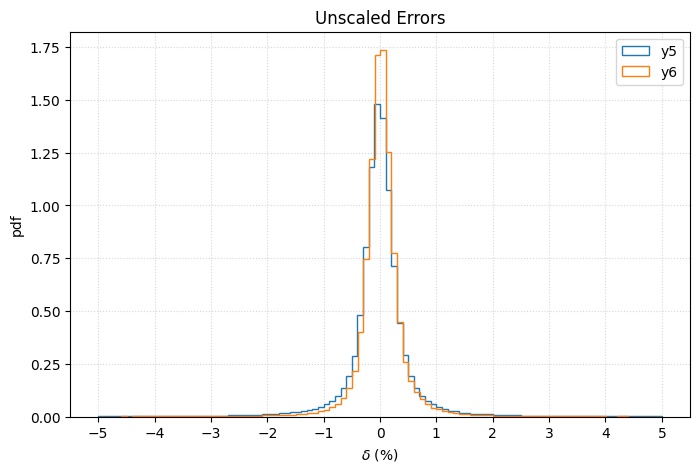

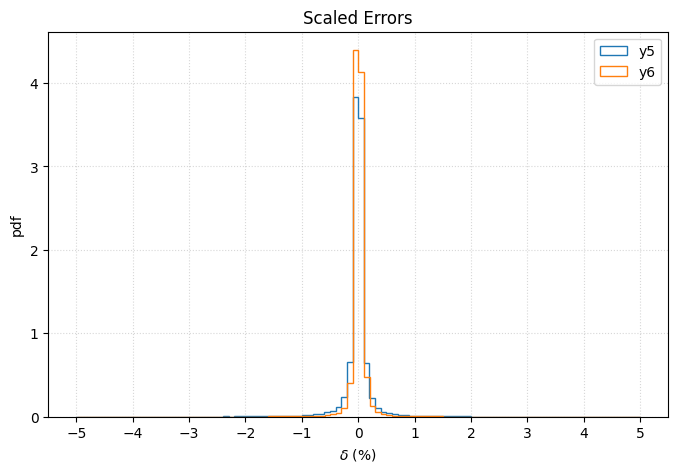

In [24]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config
)

# Ensembling different models and evaluating

### Helper functions

Custom version of MAPE with denominator regularization (for normal version, set epsilon(eps) = 0)

In [26]:
def safe_mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error with denominator guard.
    Adds eps to denominator to avoid blow-up near zero.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))

In [27]:
from sklearn.metrics import r2_score

def ensemble_from_checkpoints(model, checkpoint_paths, dataloader, device, config, eps=1e-6, verbose=True):
    """
    Evaluate ensemble of multiple checkpoints using a pre-created model.
    It loads each checkpoint, collects predictions, averages them, and runs full evaluation.
    """
    assert len(checkpoint_paths) > 0, "No checkpoints provided for ensemble"

    all_preds, all_targets = [], []
    model.eval()

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)

            preds_per_ckpt = []
            for path in checkpoint_paths:
                # load weights into same model each time
                state = torch.load(path, map_location=device, weights_only=True)
                model.load_state_dict(state)
                preds_per_ckpt.append(model(xb).cpu())

            # average predictions from all checkpoints
            mean_pred = torch.stack(preds_per_ckpt, dim=0).mean(dim=0)
            all_preds.append(mean_pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_names = config["var_y"]

    # ---------- metrics ----------
    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # ---------- unscaled ----------
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # ---------- print + plots ----------
    if verbose:
        print("\n=== Ensemble Evaluation (SCALED) ===")
        print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
        print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
        print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
        for n, v in scaled["per_target"].items():
            print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

        print("\n=== Ensemble Evaluation (UNSCALED) ===")
        print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
        print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
        print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
        for n, v in unscaled["per_target"].items():
            print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    scaled_delta   = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)
    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Ensemble Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Ensemble Errors")

    return scaled, unscaled


### Load model paths and ensemble them

Provide paths to the checkpoint files (best checkpoint) of the model trained on different seeds. 


=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002711
Overall R2  : 0.999993
Overall Abs : 99.728907
y5: MAPE=0.003113, R2=0.999994, abs=99.688702
y6: MAPE=0.002309, R2=0.999993, abs=99.769112

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004181
Overall R2  : 0.999954
Overall Abs : 99.581895
y5: MAPE=0.004728, R2=0.999924, abs=99.527249
y6: MAPE=0.003635, R2=0.999983, abs=99.636541


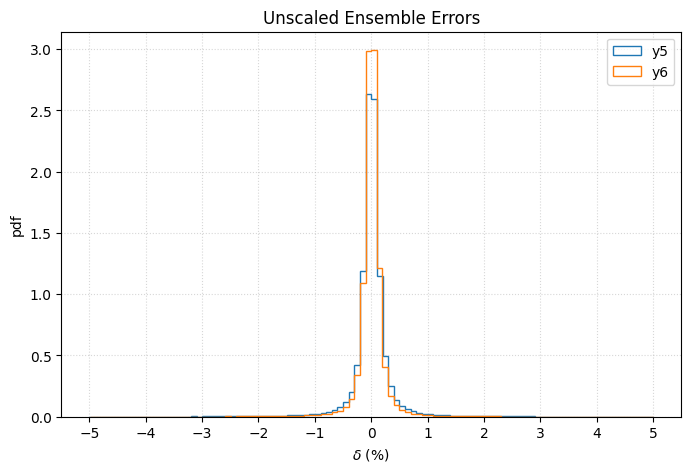

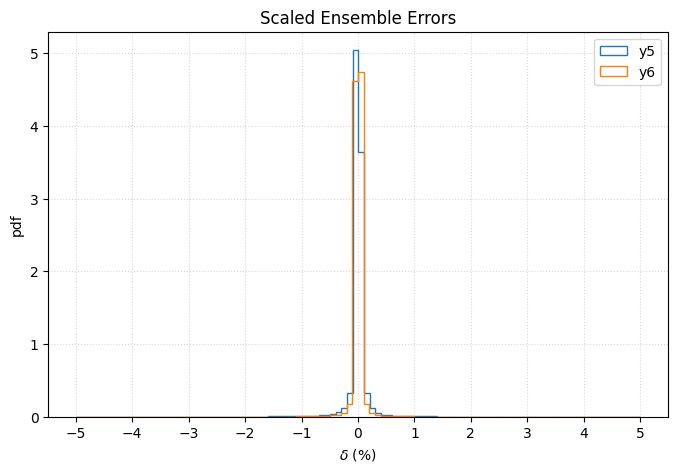

In [28]:
checkpoint_paths = [
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_smallhuberv1_30_12_5/smallhuberv1.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6exp_30_12_5/y5y6exp.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6expv2_30_12_5/y5y6expv2.best_weights.pt"
]

scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataloader=test_loader,
    device=get_device(),
    config=config,
    eps=0
)


### To compare ensembles of different sizes (and the details and plots)

Evaluation for ensemble size - 1:

=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.003605
Overall R2  : 0.999980
Overall Abs : 99.639526
y5: MAPE=0.004821, R2=0.999990, abs=99.517939
y6: MAPE=0.002389, R2=0.999970, abs=99.761113

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.006664
Overall R2  : 0.999842
Overall Abs : 99.333627
y5: MAPE=0.008434, R2=0.999739, abs=99.156556
y6: MAPE=0.004893, R2=0.999945, abs=99.510699


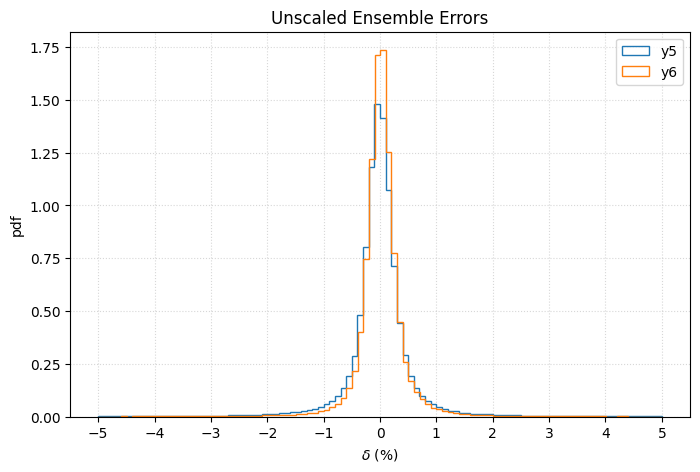

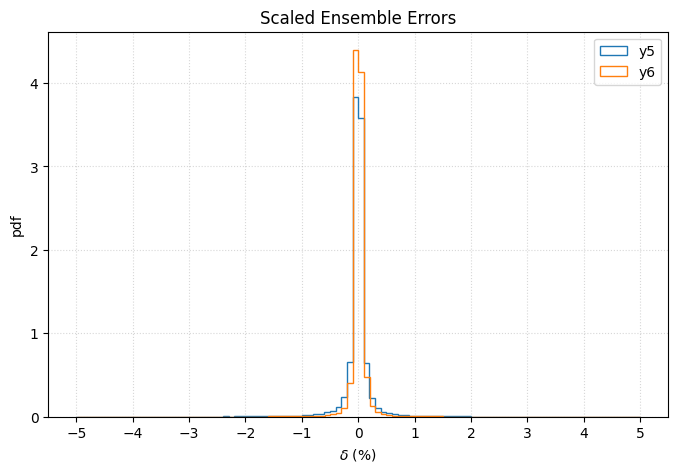


Evaluation for ensemble size - 2:

=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.003354
Overall R2  : 0.999989
Overall Abs : 99.664594
y5: MAPE=0.003887, R2=0.999994, abs=99.611261
y6: MAPE=0.002821, R2=0.999985, abs=99.717927

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.005273
Overall R2  : 0.999886
Overall Abs : 99.472690
y5: MAPE=0.005949, R2=0.999804, abs=99.405097
y6: MAPE=0.004597, R2=0.999968, abs=99.540283


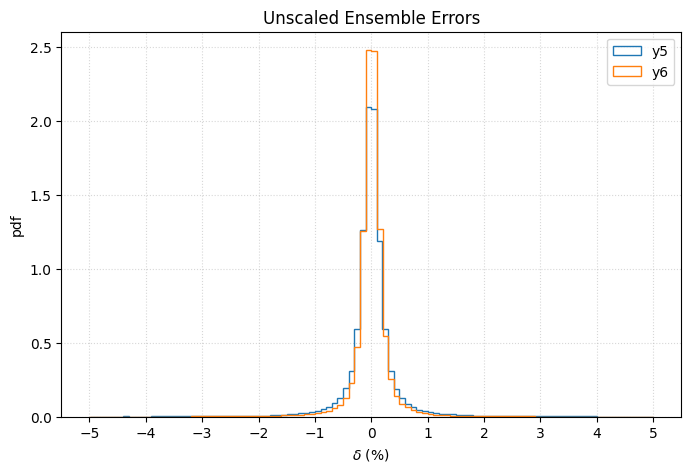

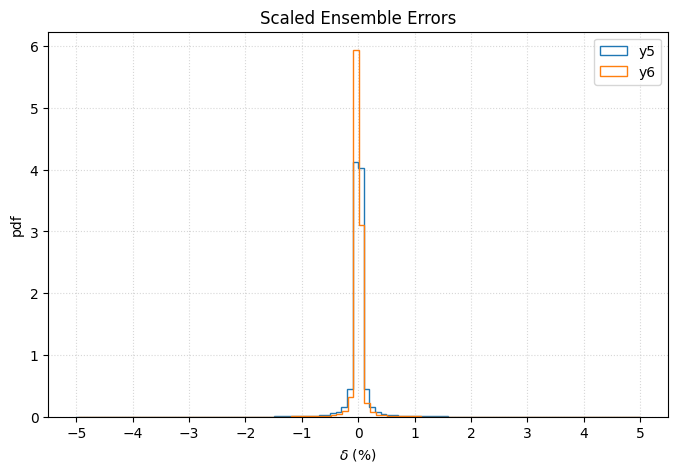


Evaluation for ensemble size - 3:

=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002779
Overall R2  : 0.999992
Overall Abs : 99.722100
y5: MAPE=0.003067, R2=0.999995, abs=99.693265
y6: MAPE=0.002491, R2=0.999990, abs=99.750936

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004420
Overall R2  : 0.999930
Overall Abs : 99.558009
y5: MAPE=0.004842, R2=0.999880, abs=99.515795
y6: MAPE=0.003998, R2=0.999979, abs=99.600222


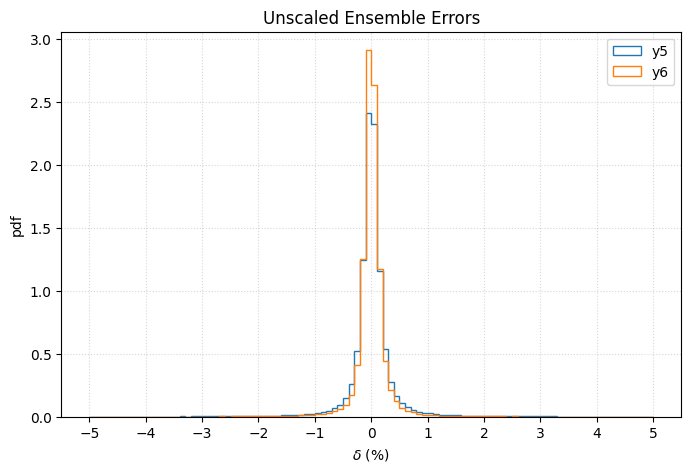

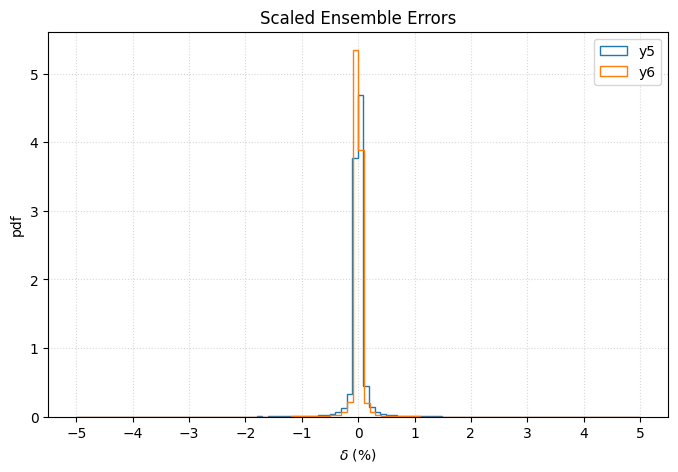


Evaluation for ensemble size - 4:

=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002711
Overall R2  : 0.999993
Overall Abs : 99.728907
y5: MAPE=0.003113, R2=0.999994, abs=99.688702
y6: MAPE=0.002309, R2=0.999993, abs=99.769112

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004181
Overall R2  : 0.999954
Overall Abs : 99.581895
y5: MAPE=0.004728, R2=0.999924, abs=99.527249
y6: MAPE=0.003635, R2=0.999983, abs=99.636541


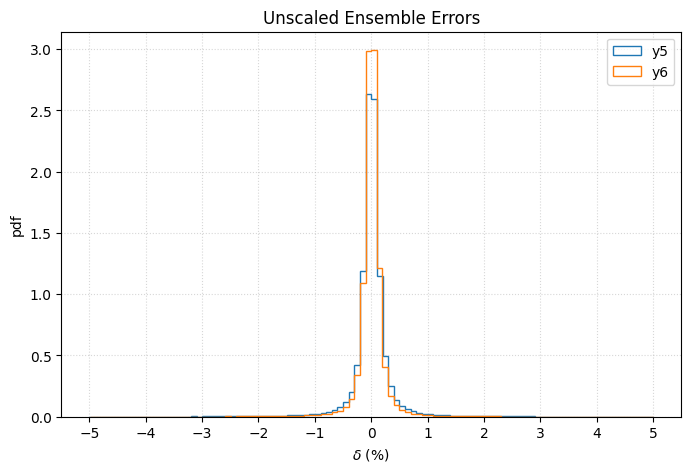

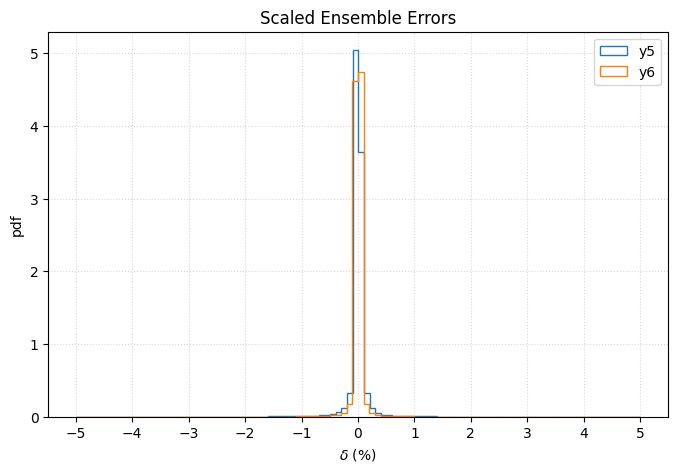

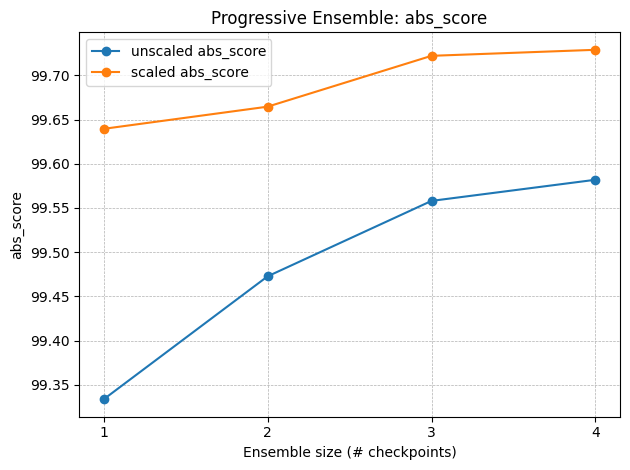

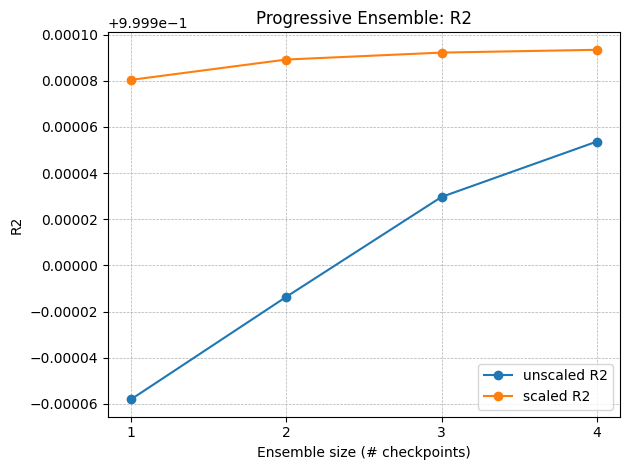

In [29]:
import matplotlib.pyplot as plt
import shutil

def progressive_ensembles(checkpoint_paths):
    """
    Returns:
      [
        [path0],
        [path0, path1],
        [path0, path1, path2],
        ...
      ]
    """
    return [checkpoint_paths[:k] for k in range(1, len(checkpoint_paths) + 1)]

ensemble_path_lists = progressive_ensembles(checkpoint_paths)

abs_unscaled = []
abs_scaled = []
r2_unscaled = []
r2_scaled = []

for k, paths_k in enumerate(ensemble_path_lists, start=1):
    print(f"Evaluation for ensemble size - {k}:")
    scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
        model=model,
        checkpoint_paths=paths_k,
        dataloader=test_loader,
        device=get_device(),
        config=config,
        eps=0,
        verbose=True
    )

    # Collect metrics
    abs_unscaled.append(unscaled_metrics["overall"]["abs_score"])
    abs_scaled.append(scaled_metrics["overall"]["abs_score"])

    r2_unscaled.append(unscaled_metrics["overall"]["R2"])
    r2_scaled.append(scaled_metrics["overall"]["R2"])

    # print(f"Ensemble size {k}:")
    # print(f"  unscaled abs_score = {abs_unscaled[-1]}")
    # print(f"  scaled   abs_score = {abs_scaled[-1]}")
    # print(f"  unscaled R2        = {r2_unscaled[-1]}")
    # print(f"  scaled   R2        = {r2_scaled[-1]}")
    print('=' * shutil.get_terminal_size().columns)
    print()

x = list(range(1, len(ensemble_path_lists) + 1))

# Plot abs_score (unscaled + scaled)
plt.figure()
plt.plot(x, abs_unscaled, marker="o", label="unscaled abs_score")
plt.plot(x, abs_scaled, marker="o", label="scaled abs_score")
plt.xticks(x)
plt.xlabel("Ensemble size (# checkpoints)")
plt.ylabel("abs_score")
plt.title("Progressive Ensemble: abs_score")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Plot R2 (unscaled + scaled)
plt.figure()
plt.plot(x, r2_unscaled, marker="o", label="unscaled R2")
plt.plot(x, r2_scaled, marker="o", label="scaled R2")
plt.xticks(x)
plt.xlabel("Ensemble size (# checkpoints)")
plt.ylabel("R2")
plt.title("Progressive Ensemble: R2")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
